# Session 2 — Modeling Randomness & Input Analysis

**Course:** Decision Modelling — Simulation Part
**Session:** 2 of 12 (simulation portion)

## Learning objectives

By the end of this session you should be able to:

- Fit probability distributions to real, empirical data
- Generate random variates from a fitted distribution
- Test whether a distributional assumption is statistically reasonable (goodness-of-fit)
- Justify an input-modeling choice — not just produce one

## Where this session fits

- **Looking back:** Session 1 introduced randomness informally (a fair die, a fixed-probability arrival process). Today we stop assuming we know the "true" distribution and instead learn how to infer it from data.
- **Looking ahead:** every Monte Carlo model (Sessions 3–4) and every SimPy model (Sessions 6–7) needs random inputs — interarrival times, service times, demand. The techniques from today are exactly how you'll justify those inputs rather than picking them arbitrarily.
- **Cross-course link:** Advanced Data Analysis covers forecasting — a demand forecast is itself often the starting point for an input distribution here (e.g. a forecast plus its historical error distribution can become a demand *distribution*, not just a point estimate).


## Further reading (supplementary, not required)

- A focused chapter or paper on distribution fitting and goodness-of-fit testing for simulation input modeling — check the course reading list for the current reference.
- The datasets used below are real, anonymized measurements reused from a prior iteration of this course's input-analysis material.

No textbook is required for this course; this is supplementary reading for this session specifically.


## 1. Why input modeling matters

A simulation model is only as trustworthy as the random inputs that drive it. If we simulate arrivals as "uniformly random" when in reality they cluster around lunchtime, or model service times as constant when they're highly variable, our conclusions about queues, costs, and service levels will be wrong — no matter how carefully we code the rest of the model.

**Input modeling is where reality enters the simulation.** This is exactly why we treat it as a first-class topic rather than an afterthought: the decision-modeling value of a simulation study rests on the credibility of its inputs, not just the sophistication of its logic.


## 2. Common distributions in OSCM simulation

| Distribution | Typical use | Why |
|---|---|---|
| **Exponential** | Time between arrivals (interarrival times) | Memoryless; arises naturally from Poisson arrival processes |
| **Poisson** | Number of arrivals in a fixed interval | Counts of independent events over a fixed time window |
| **Normal** | Service/processing times that cluster symmetrically around a mean | Central-limit-type behavior when many small factors add up |
| **Lognormal / Gamma** | Service or repair times that are positive and right-skewed | Many real processing times can't be negative and have a long right tail |
| **Uniform / Triangular** | Quick, low-data-availability estimates (min, max, or min-mode-max) | Useful when only rough judgment, not much data, is available |
| **Empirical distribution** | Anything that doesn't fit a clean theoretical shape well | Resamples directly from observed data — no assumption of shape, but also no ability to extrapolate beyond what was observed |

Picking the right entry in this table is a judgment call informed by data — which is exactly what the rest of this session helps you do systematically rather than by guesswork.


## 3. The input-modeling workflow

A defensible input-modeling process generally follows these steps:

1. **Collect data** — real measurements from the system (or the closest available proxy)
2. **Visualize** — histogram, summary statistics; get a feel for shape, skew, and range
3. **Hypothesize candidate distribution(s)** — informed by the shape *and* by domain knowledge (Section 2's table)
4. **Estimate parameters** — typically via Maximum Likelihood Estimation (MLE)
5. **Test goodness-of-fit** — does the data plausibly come from the fitted distribution? (e.g. Kolmogorov–Smirnov, chi-square)
6. **Compare candidates** — if more than one distribution seemed plausible, compare fits
7. **Select and justify** — document *why* this distribution and these parameters were chosen

We'll now work through this process twice: once for **continuous** data (order times) and once for **discrete count** data (arrivals per interval).


## 4. Hands-on: fitting a continuous distribution

The dataset below (`data/session02_order_times.txt`) contains 1000 real, anonymized order-processing times (in minutes), reused from a prior offering of this course's input-analysis material.


n = 1000
mean = 12.00, std = 1.64
min = 6.87, max = 17.51


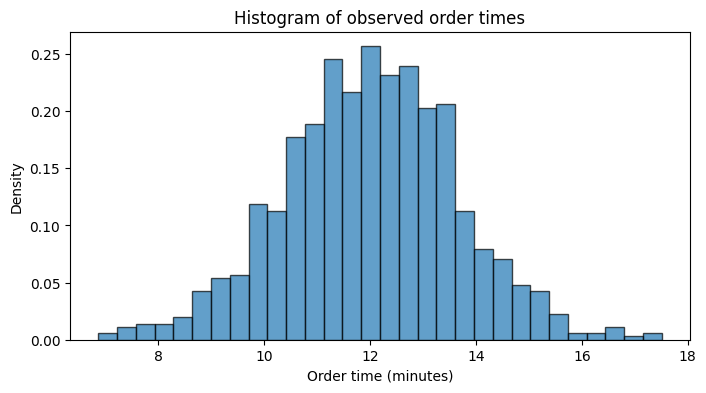

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

order_times = np.loadtxt('../data/session02_order_times.txt')

print(f"n = {len(order_times)}")
print(f"mean = {order_times.mean():.2f}, std = {order_times.std():.2f}")
print(f"min = {order_times.min():.2f}, max = {order_times.max():.2f}")

plt.figure(figsize=(8, 4))
plt.hist(order_times, bins=30, density=True, edgecolor='black', alpha=0.7)
plt.xlabel('Order time (minutes)')
plt.ylabel('Density')
plt.title('Histogram of observed order times')
plt.show()


The histogram looks roughly bell-shaped and symmetric — a **Normal** distribution is a reasonable first candidate. Let's fit it via MLE and overlay the fitted density on the histogram.


Fitted Normal: mu = 11.997, sigma = 1.640


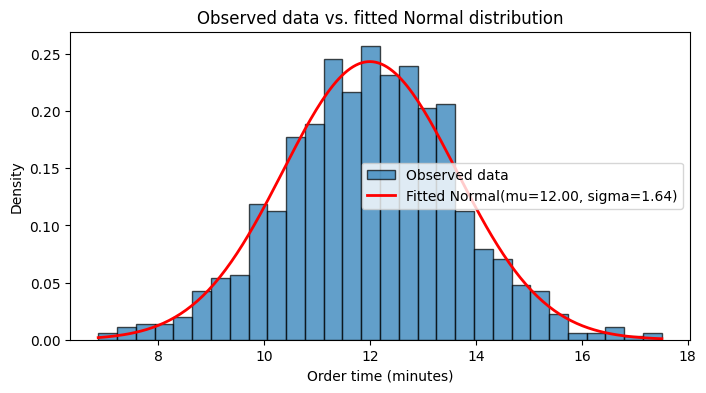

In [2]:
# Fit a Normal distribution via MLE
mu_hat, sigma_hat = stats.norm.fit(order_times)
print(f"Fitted Normal: mu = {mu_hat:.3f}, sigma = {sigma_hat:.3f}")

x = np.linspace(order_times.min(), order_times.max(), 200)
fitted_pdf = stats.norm.pdf(x, mu_hat, sigma_hat)

plt.figure(figsize=(8, 4))
plt.hist(order_times, bins=30, density=True, edgecolor='black', alpha=0.7, label='Observed data')
plt.plot(x, fitted_pdf, 'r-', linewidth=2, label=f'Fitted Normal(mu={mu_hat:.2f}, sigma={sigma_hat:.2f})')
plt.xlabel('Order time (minutes)')
plt.ylabel('Density')
plt.legend()
plt.title('Observed data vs. fitted Normal distribution')
plt.show()


Visually the fit looks reasonable — but "looks reasonable" is not a statistical test. Let's formally test the goodness-of-fit using the **Kolmogorov–Smirnov (KS) test**, which compares the empirical distribution of the data to the fitted theoretical CDF.

**Hypotheses:**
- H0: the data come from the fitted Normal distribution
- H1: the data do not come from the fitted Normal distribution

A small p-value (conventionally < 0.05) would lead us to reject H0 — i.e., reject the Normal assumption.


In [3]:
ks_stat, p_value = stats.kstest(order_times, 'norm', args=(mu_hat, sigma_hat))
print(f"KS statistic = {ks_stat:.4f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0 at the 5% level: Normal is not a statistically adequate fit.")
else:
    print("Fail to reject H0 at the 5% level: Normal is a statistically plausible fit.")


KS statistic = 0.0202, p-value = 0.8012
Fail to reject H0 at the 5% level: Normal is a statistically plausible fit.


**Important interpretation note:** "fail to reject H0" does **not** mean "the data definitely *is* Normal" — it means the data is *not inconsistent* with a Normal assumption at this sample size. With very large samples, even tiny, practically irrelevant deviations can produce a significant test statistic; with very small samples, almost any distribution will "pass." Goodness-of-fit tests are evidence to weigh alongside the visual fit and domain knowledge — not a mechanical yes/no oracle.


## 5. Hands-on: fitting a discrete distribution

Now the discrete case: `data/session02_arrivals_per_interval.txt` contains 5000 real, anonymized counts — the number of arrivals observed in each of 5000 fixed time intervals.


n = 5000
mean = 4.955, variance = 5.025


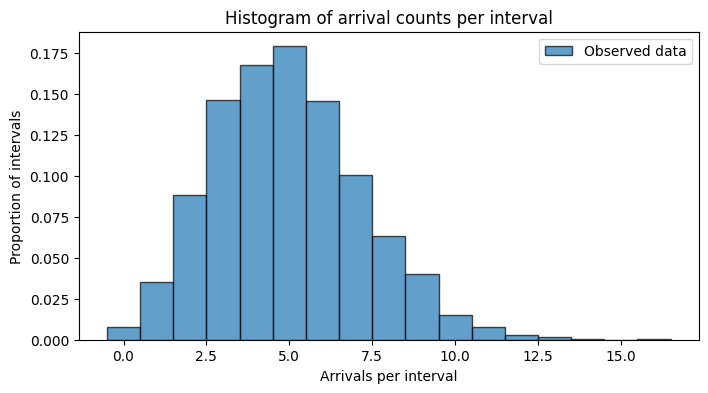

In [4]:
arrivals = np.loadtxt('../data/session02_arrivals_per_interval.txt').astype(int)

print(f"n = {len(arrivals)}")
print(f"mean = {arrivals.mean():.3f}, variance = {arrivals.var():.3f}")

plt.figure(figsize=(8, 4))
bins = np.arange(arrivals.min(), arrivals.max() + 2) - 0.5
plt.hist(arrivals, bins=bins, density=True, edgecolor='black', alpha=0.7, label='Observed data')
plt.xlabel('Arrivals per interval')
plt.ylabel('Proportion of intervals')
plt.title('Histogram of arrival counts per interval')
plt.legend()
plt.show()


**Why Poisson is the natural first candidate:** counts of independent arrivals in a fixed interval are the textbook setting for a Poisson distribution. A useful diagnostic: for a Poisson distribution, the **mean and variance should be approximately equal**. Check the numbers printed above — are they close?

Let's fit the Poisson distribution (its single parameter, lambda, is estimated by MLE as simply the sample mean) and test fit with a **chi-square goodness-of-fit test**, which is the standard choice for discrete/count data (KS is designed for continuous distributions).


In [5]:
lam_hat = arrivals.mean()
print(f"Fitted Poisson: lambda = {lam_hat:.3f}")

# Build observed frequency table over the observed range of counts
values, observed_counts = np.unique(arrivals, return_counts=True)

# Expected counts under the fitted Poisson
# (rescaled so expected and observed totals match exactly -- we're only
# summing probability mass over the *observed* range of values, not the
# Poisson's full infinite support, so a small renormalization is needed)
expected_props = stats.poisson.pmf(values, lam_hat)
expected_counts = expected_props * len(arrivals)
expected_counts *= observed_counts.sum() / expected_counts.sum()

# Compare observed vs expected visually
comparison = pd.DataFrame({
    'arrivals': values,
    'observed': observed_counts,
    'expected (Poisson fit)': expected_counts.round(1)
})
print(comparison)

chi2_stat, p_value = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)
print(f"\nChi-square statistic = {chi2_stat:.3f}, p-value = {p_value:.4f}")


Fitted Poisson: lambda = 4.955
    arrivals  observed  expected (Poisson fit)
0          0        39                    35.2
1          1       175                   174.6
2          2       440                   432.6
3          3       730                   714.6
4          4       836                   885.2
5          5       894                   877.3
6          6       729                   724.5
7          7       503                   512.9
8          8       315                   317.7
9          9       200                   174.9
10        10        74                    86.7
11        11        38                    39.0
12        12        15                    16.1
13        13         8                     6.1
14        14         2                     2.2
15        16         2                     0.2

Chi-square statistic = 24.486, p-value = 0.0573


### Discussion: interpreting the chi-square result

- If the p-value is small, what would that tell you about the Poisson assumption — and what real-world features of arrivals (e.g. batch arrivals, time-varying arrival rates) might explain a poor fit?
- The chi-square test can be sensitive to how counts are grouped/binned, especially when some categories have very few observations. Does that concern apply here, given how many distinct values `arrivals` takes?


## 6. Generating random variates from a fitted distribution

Fitting a distribution is only useful if we can then **sample** from it to drive a simulation. `scipy.stats` makes this direct once you have fitted parameters.


In [6]:
rng = np.random.default_rng(seed=42)

# Draw 10 simulated order times from the fitted Normal
simulated_order_times = stats.norm.rvs(loc=mu_hat, scale=sigma_hat, size=10, random_state=rng)
print("Simulated order times:", np.round(simulated_order_times, 2))

# Draw 10 simulated interval arrival counts from the fitted Poisson
simulated_arrivals = stats.poisson.rvs(mu=lam_hat, size=10, random_state=rng)
print("Simulated arrival counts:", simulated_arrivals)


Simulated order times: [12.5  10.29 13.23 13.54  8.8   9.86 12.21 11.48 11.97 10.6 ]
Simulated arrival counts: [7 9 6 3 8 3 7 8 5 6]


Notice the Normal fit can, in principle, generate a *negative* order time (unlikely given these parameters, but not impossible) — a reminder that a fitted distribution is a convenient approximation, not a perfect description of reality. This is exactly the kind of judgment call worth documenting when you justify an input choice: does the theoretical support of the distribution make physical sense for this quantity?


## Exercise (guided): mini input-analysis lab

You're given a new (synthetic) dataset representing **service times at a second workstation**, generated below. Work through the full input-modeling workflow from Section 3:

1. Visualize the data (histogram, summary statistics)
2. Propose a candidate distribution based on the shape (hint: service times are positive and often right-skewed — consider `stats.gamma` or `stats.lognorm` in addition to Normal)
3. Fit your candidate via MLE (`stats.<dist>.fit(data)`)
4. Test goodness-of-fit with the KS test
5. State, in a sentence, whether you'd adopt this distribution for a simulation model and why


In [7]:
# Synthetic "workstation 2" service time data — do not change this cell
_rng = np.random.default_rng(7)
workstation2_times = _rng.gamma(shape=3.0, scale=2.0, size=400)

# EXERCISE
# TODO: 1. Plot a histogram of workstation2_times and print summary statistics

# TODO: 2-3. Fit a candidate distribution (try more than one if you like)

# TODO: 4. Run a KS goodness-of-fit test against your fitted distribution

# TODO: 5. Print one sentence stating your conclusion


<details>
<summary>Solution (click to expand)</summary>

```python
# SOLUTION
plt.figure(figsize=(8, 4))
plt.hist(workstation2_times, bins=30, density=True, edgecolor='black', alpha=0.7)
plt.xlabel('Service time')
plt.ylabel('Density')
plt.title('Workstation 2 service times')
plt.show()

print(f"mean = {workstation2_times.mean():.2f}, std = {workstation2_times.std():.2f}")
print(f"min = {workstation2_times.min():.2f}, max = {workstation2_times.max():.2f}")

# Candidate: Gamma
shape_hat, loc_hat, scale_hat = stats.gamma.fit(workstation2_times, floc=0)
print(f"Fitted Gamma: shape = {shape_hat:.3f}, scale = {scale_hat:.3f}")

ks_stat, p_value = stats.kstest(workstation2_times, 'gamma', args=(shape_hat, loc_hat, scale_hat))
print(f"KS statistic = {ks_stat:.4f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: reject the Gamma assumption at the 5% level.")
else:
    print("Conclusion: the Gamma distribution is a statistically plausible fit and is a "
          "reasonable choice given the positive, right-skewed shape of the data.")
```
</details>


### Discussion questions

1. Why does it make sense to fix the location parameter to 0 (`floc=0`) when fitting a Gamma distribution to service times specifically?
2. If your forecast from Advanced Data Analysis gave you a point forecast *and* a historical distribution of forecast errors, how might you combine the two into a distribution suitable as a simulation input (rather than just simulating with the point forecast as a constant)?
3. Suppose two candidate distributions both pass their goodness-of-fit test. What other considerations (beyond the p-value) might help you choose between them for a simulation study?


## Wrap-up

Today we:

- Established why input modeling matters: it's where real-world data enters a simulation, and simulation conclusions are only as credible as this step
- Walked through the full input-modeling workflow: visualize → hypothesize → fit → test → justify
- Fitted and tested a continuous distribution (Normal, via KS test) to real order-time data
- Fitted and tested a discrete distribution (Poisson, via chi-square test) to real arrival-count data
- Generated random variates from fitted distributions — the building block for every Monte Carlo and DES model from here on
- Practiced the full workflow independently on a new dataset

**Next session:** Fundamentals of Monte Carlo Simulation — we'll use exactly this kind of fitted input distribution to build a full Monte Carlo model (the Newsvendor problem) and compute point and interval estimates of a decision's performance under uncertainty.
